In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.4f}".format)

FIXED_LAM = 1.9675

TENOR_YEARS = {
    "1mo": 1/12, "3mo": 3/12, "6mo": 6/12,
    "1yr": 1, "2yr": 2, "3yr": 3, "5yr": 5,
    "7yr": 7, "10yr": 10, "20yr": 20, "30yr": 30,
}
TENORS = list(TENOR_YEARS.keys())
TAUS   = list(TENOR_YEARS.values())

def ns_yield(tau, beta0, beta1, beta2, lam=FIXED_LAM):
    tau = np.maximum(tau, 1e-6)
    factor = (1 - np.exp(-tau / lam)) / (tau / lam)
    return beta0 + beta1 * factor + beta2 * (factor - np.exp(-tau / lam))

def curve_from_params(b0, b1, b2, taus=TAUS):
    return np.array([ns_yield(tau, b0, b1, b2) for tau in taus])

In [2]:
yields  = pd.read_csv("data/yields_clean.csv",  index_col="date", parse_dates=True)
ns_dl   = pd.read_csv("data/ns_params_dl.csv",  index_col="date", parse_dates=True)
mc_env  = pd.read_csv("data/dl_mc_yield_envelopes.csv", index_col=0)

# Base curve = most recent date with full data
base_date  = yields.dropna(thresh=9).index[-1]
base_row   = yields.loc[base_date, TENORS]
base_curve = base_row.values.astype(float)

print(f"Base curve date : {base_date.date()}")
print(f"Base curve (%)  :")
for t, y in zip(TENORS, base_curve):
    print(f"  {t:>4s} : {y:.3f}")

# Save base curve
base_df = pd.Series(base_curve, index=TENORS, name="yield")
base_df.to_csv("data/base_curve.csv", header=True)

Base curve date : 2026-04-06
Base curve (%)  :
   1mo : 3.720
   3mo : 3.720
   6mo : 3.740
   1yr : 3.720
   2yr : 3.840
   3yr : 3.880
   5yr : 3.980
   7yr : 4.160
  10yr : 4.340
  20yr : 4.890
  30yr : 4.890


In [3]:
# ── CELL 3: Standard Scenario Definitions ────────────────────
# Each scenario is defined as a bps shift per tenor
# Positive = rates up, Negative = rates down

def make_shifts(tenors, shift_dict):
    """
    Build a full shift array from a partial spec.
    shift_dict: {tenor: bps_shift} — unspecified tenors get 0
    """
    return np.array([shift_dict.get(t, 0) for t in tenors]) / 100  # convert bps to %

# ── Short-end vs long-end tenor splits ──
SHORT = ["1mo", "3mo", "6mo", "1yr", "2yr"]
LONG  = ["5yr", "7yr", "10yr", "20yr", "30yr"]

standard_scenarios = {
    # Parallel shifts
    "parallel_up_100":   {t: +100 for t in TENORS},
    "parallel_up_200":   {t: +200 for t in TENORS},
    "parallel_up_300":   {t: +300 for t in TENORS},
    "parallel_down_100": {t: -100 for t in TENORS},
    "parallel_down_200": {t: -200 for t in TENORS},

    # Steepeners (long end rises more / falls less than short end)
    "bear_steepener":    {**{t: +50  for t in SHORT}, **{t: +150 for t in LONG}},
    "bull_steepener":    {**{t: -50  for t in SHORT}, **{t: -150 for t in LONG}},

    # Flatteners (short end rises more / falls more than long end)
    "bear_flattener":    {**{t: +150 for t in SHORT}, **{t: +50  for t in LONG}},
    "bull_flattener":    {**{t: -150 for t in SHORT}, **{t: -50  for t in LONG}},

    # Special shapes
    "inversion":         {**{t: +200 for t in SHORT}, **{t: 0    for t in LONG}},
    "hump":              {"2yr": +150, "3yr": +150, "5yr": +150,
                          "1mo": 0, "3mo": 0, "6mo": 0, "1yr": 0,
                          "7yr": 0, "10yr": 0, "20yr": 0, "30yr": 0},
}

print(f"Standard scenarios defined: {len(standard_scenarios)}")
for name in standard_scenarios:
    print(f"  {name}")

Standard scenarios defined: 11
  parallel_up_100
  parallel_up_200
  parallel_up_300
  parallel_down_100
  parallel_down_200
  bear_steepener
  bull_steepener
  bear_flattener
  bull_flattener
  inversion
  hump


In [4]:
#── CELL 4: Historical Scenario Extraction ────────────────────
# Extract actual curve moves from FRED data for 3 major events
# Move = end_date yield - start_date yield per tenor

historical_events = {
    "taper_tantrum_2013": {
        "start": "2013-05-01",
        "end":   "2013-09-05",
        "desc":  "Taper Tantrum (May–Sep 2013)",
    },
    "covid_shock_2020": {
        "start": "2020-02-19",
        "end":   "2020-03-09",
        "desc":  "COVID Flight to Safety (Feb–Mar 2020)",
    },
    "rate_shock_2022": {
        "start": "2022-01-03",
        "end":   "2022-12-30",
        "desc":  "2022 Rate Shock (Full Year)",
    },
}

hist_scenarios = {}
hist_moves     = {}

for name, event in historical_events.items():
    # Find nearest available dates
    start_idx = yields.index.get_indexer([event["start"]], method="nearest")[0]
    end_idx   = yields.index.get_indexer([event["end"]],   method="nearest")[0]

    start_row = yields.iloc[start_idx][TENORS].values.astype(float)
    end_row   = yields.iloc[end_idx][TENORS].values.astype(float)

    move = end_row - start_row   # in percentage points
    stressed_curve = base_curve + move

    hist_scenarios[name] = stressed_curve
    hist_moves[name]     = move

    print(f"\n{event['desc']}")
    print(f"  Dates  : {yields.index[start_idx].date()} → {yields.index[end_idx].date()}")
    print(f"  Moves (bps):")
    for t, m in zip(TENORS, move * 100):
        print(f"    {t:>4s}: {m:+.1f}bps")


Taper Tantrum (May–Sep 2013)
  Dates  : 2013-05-01 → 2013-09-05
  Moves (bps):
     1mo: +0.0bps
     3mo: -4.0bps
     6mo: -2.0bps
     1yr: +5.0bps
     2yr: +32.0bps
     3yr: +67.0bps
     5yr: +120.0bps
     7yr: +138.0bps
    10yr: +132.0bps
    20yr: +120.0bps
    30yr: +105.0bps

COVID Flight to Safety (Feb–Mar 2020)
  Dates  : 2020-02-19 → 2020-03-09
  Moves (bps):
     1mo: -104.0bps
     3mo: -125.0bps
     6mo: -129.0bps
     1yr: -116.0bps
     2yr: -104.0bps
     3yr: -99.0bps
     5yr: -95.0bps
     7yr: -94.0bps
    10yr: -102.0bps
    20yr: -99.0bps
    30yr: -102.0bps

2022 Rate Shock (Full Year)
  Dates  : 2022-01-03 → 2022-12-30
  Moves (bps):
     1mo: +407.0bps
     3mo: +434.0bps
     6mo: +454.0bps
     1yr: +433.0bps
     2yr: +363.0bps
     3yr: +318.0bps
     5yr: +262.0bps
     7yr: +241.0bps
    10yr: +225.0bps
    20yr: +209.0bps
    30yr: +196.0bps


In [5]:
#── CELL 5: Assemble Full Scenario Library ───────────────────
all_scenarios = {}

# Standard scenarios
for name, shift_dict in standard_scenarios.items():
    shifts = make_shifts(TENORS, shift_dict)
    all_scenarios[name] = base_curve + shifts

# Historical scenarios
for name, curve in hist_scenarios.items():
    all_scenarios[name] = curve

# MC percentile scenarios from notebook 02
for col in mc_env.columns:
    all_scenarios[f"mc_{col}"] = mc_env[col].values

print(f"\nTotal scenarios in library: {len(all_scenarios)}")
for name in all_scenarios:
    print(f"  {name}")


Total scenarios in library: 19
  parallel_up_100
  parallel_up_200
  parallel_up_300
  parallel_down_100
  parallel_down_200
  bear_steepener
  bull_steepener
  bear_flattener
  bull_flattener
  inversion
  hump
  taper_tantrum_2013
  covid_shock_2020
  rate_shock_2022
  mc_p5
  mc_p25
  mc_p50
  mc_p75
  mc_p95


In [6]:
# Wide format: rows = scenarios, columns = tenors
scenarios_df = pd.DataFrame(all_scenarios, index=TENORS).T
scenarios_df.index.name = "scenario"
scenarios_df.to_csv("data/scenarios.csv")

# Also save bps moves vs base
moves_df = (scenarios_df - base_curve) * 100
moves_df.index.name = "scenario"
moves_df.to_csv("data/scenario_moves.csv")

print(f"Saved {len(scenarios_df)} scenarios to data/scenarios.csv")
print(f"Saved bps moves to data/scenario_moves.csv")
scenarios_df.round(4)

Saved 19 scenarios to data/scenarios.csv
Saved bps moves to data/scenario_moves.csv


,1mo,3mo,6mo,1yr,2yr,3yr,5yr,7yr,10yr,20yr,30yr
scenario,,,,,,,,,,,
parallel_up_100,4.7200,4.7200,4.7400,4.7200,4.8400,4.8800,4.9800,5.1600,5.3400,5.8900,5.8900
parallel_up_200,5.7200,5.7200,5.7400,5.7200,5.8400,5.8800,5.9800,6.1600,6.3400,6.8900,6.8900
parallel_up_300,6.7200,6.7200,6.7400,6.7200,6.8400,6.8800,6.9800,7.1600,7.3400,7.8900,7.8900
parallel_down_100,2.7200,2.7200,2.7400,2.7200,2.8400,2.8800,2.9800,3.1600,3.3400,3.8900,3.8900
parallel_down_200,1.7200,1.7200,1.7400,1.7200,1.8400,1.8800,1.9800,2.1600,2.3400,2.8900,2.8900
bear_steepener,4.2200,4.2200,4.2400,4.2200,4.3400,3.8800,5.4800,5.6600,5.8400,6.3900,6.3900
bull_steepener,3.2200,3.2200,3.2400,3.2200,3.3400,3.8800,2.4800,2.6600,2.8400,3.3900,3.3900
bear_flattener,5.2200,5.2200,5.2400,5.2200,5.3400,3.8800,4.4800,4.6600,4.8400,5.3900,5.3900
bull_flattener,2.2200,2.2200,2.2400,2.2200,2.3400,3.8800,3.4800,3.6600,3.8400,4.3900,4.3900


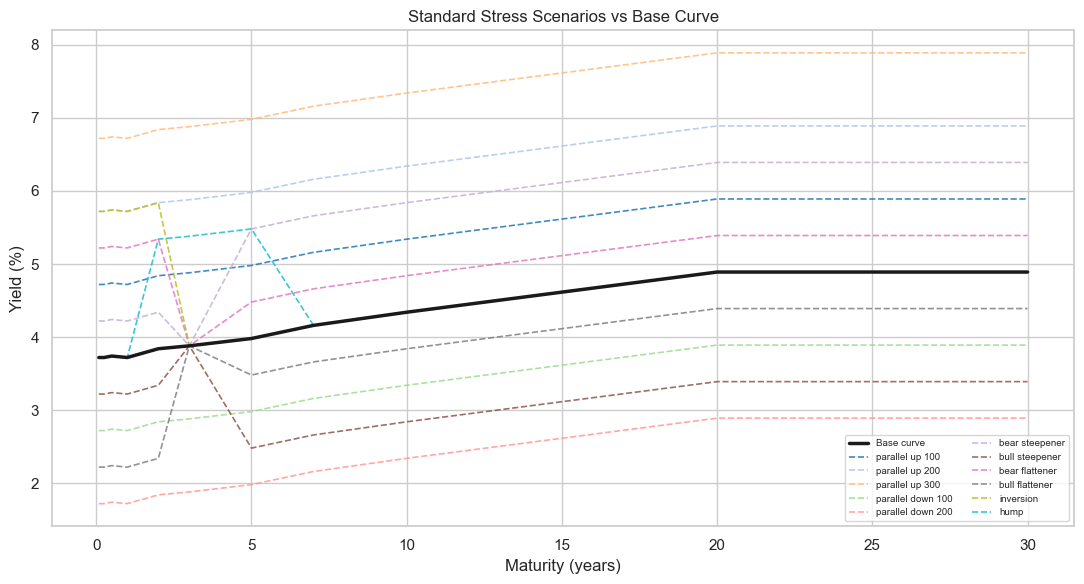

In [7]:
std_names = list(standard_scenarios.keys())
colors = plt.cm.tab20(np.linspace(0, 1, len(std_names) + 1))

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(TAUS, base_curve, "k-", linewidth=2.5, label="Base curve", zorder=10)

for i, name in enumerate(std_names):
    ax.plot(TAUS, all_scenarios[name], color=colors[i],
            linewidth=1.2, linestyle="--", label=name.replace("_", " "), alpha=0.85)

ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield (%)")
ax.set_title("Standard Stress Scenarios vs Base Curve")
ax.legend(fontsize=7, ncol=2, loc="lower right")
plt.tight_layout()
plt.savefig("data/fig_standard_scenarios.png", dpi=150)
plt.show()

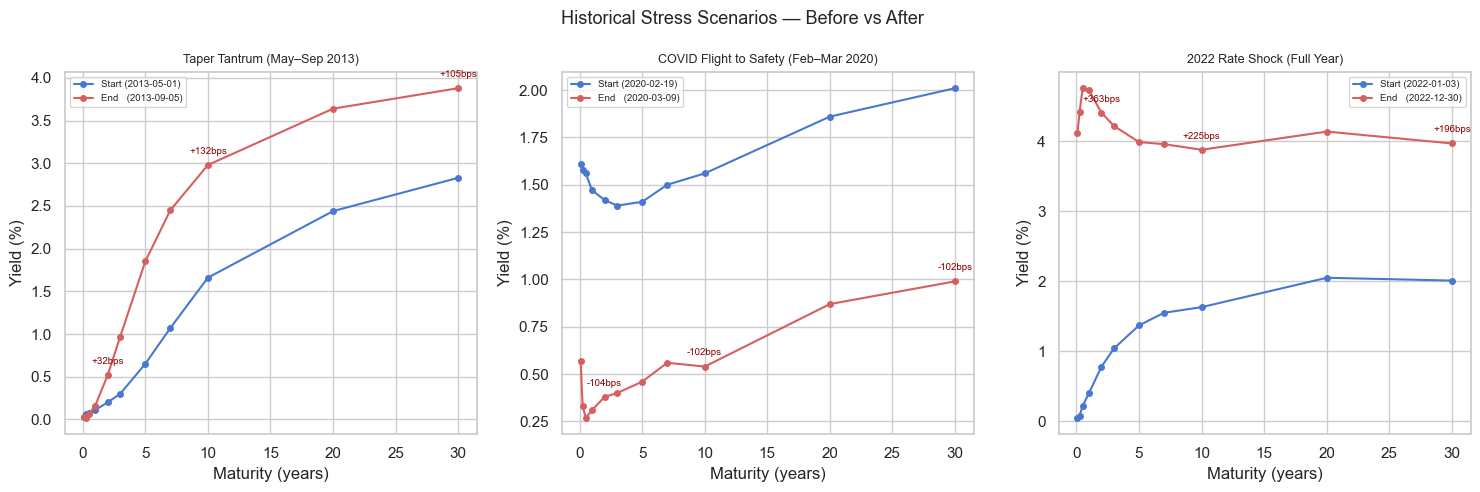

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

event_list = list(historical_events.items())
for ax, (name, event) in zip(axes, event_list):
    start_idx = yields.index.get_indexer([event["start"]], method="nearest")[0]
    end_idx   = yields.index.get_indexer([event["end"]],   method="nearest")[0]
    start_curve = yields.iloc[start_idx][TENORS].values.astype(float)
    end_curve   = yields.iloc[end_idx][TENORS].values.astype(float)

    ax.plot(TAUS, start_curve, "b-o",  markersize=4, linewidth=1.5, label=f"Start ({yields.index[start_idx].date()})")
    ax.plot(TAUS, end_curve,   "r-o",  markersize=4, linewidth=1.5, label=f"End   ({yields.index[end_idx].date()})")

    # Annotate moves at key tenors
    for t_label in ["2yr", "10yr", "30yr"]:
        t_idx = TENORS.index(t_label)
        move  = (end_curve[t_idx] - start_curve[t_idx]) * 100
        ax.annotate(f"{move:+.0f}bps",
                    xy=(TAUS[t_idx], end_curve[t_idx]),
                    xytext=(0, 8), textcoords="offset points",
                    fontsize=7, ha="center", color="darkred")

    ax.set_title(event["desc"], fontsize=9)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=7)

plt.suptitle("Historical Stress Scenarios — Before vs After", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_historical_scenarios.png", dpi=150)
plt.show()

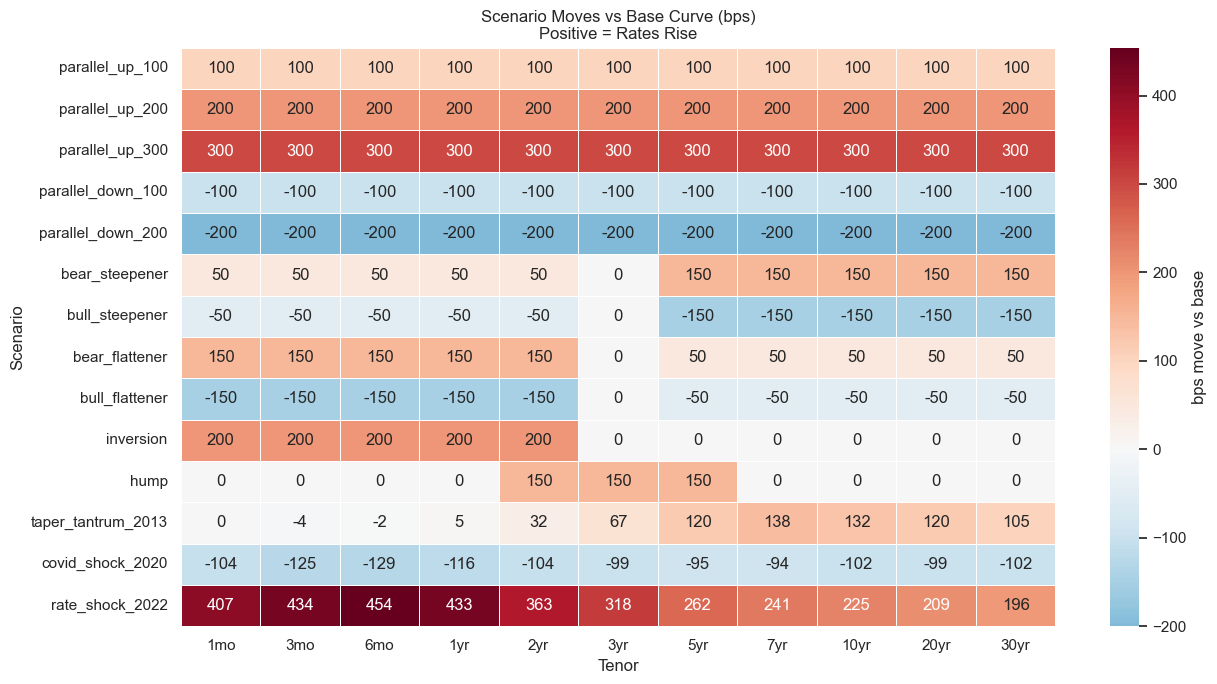

In [9]:
# Show bps moves for all non-MC scenarios in a heatmap

non_mc = [s for s in moves_df.index if not s.startswith("mc_")]
heatmap_data = moves_df.loc[non_mc].astype(float)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={"label": "bps move vs base"})
ax.set_title("Scenario Moves vs Base Curve (bps)\nPositive = Rates Rise", fontsize=12)
ax.set_xlabel("Tenor")
ax.set_ylabel("Scenario")
plt.tight_layout()
plt.savefig("data/fig_scenario_heatmap.png", dpi=150)
plt.show()

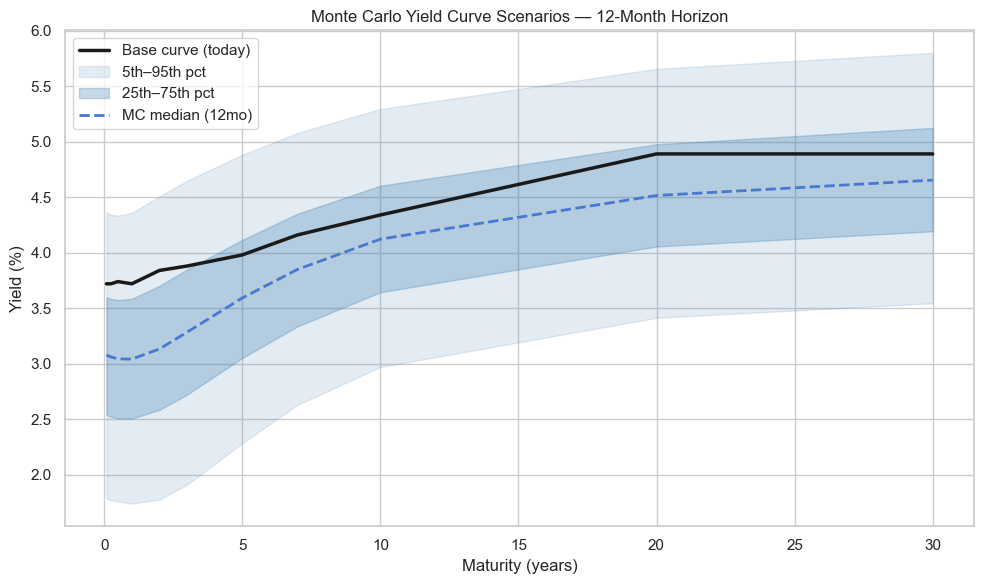

In [10]:
mc_scenarios = {k: v for k, v in all_scenarios.items() if k.startswith("mc_")}

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(TAUS, base_curve, "k-", linewidth=2.5, label="Base curve (today)", zorder=10)

pct_colors = {
    "mc_p5":  ("lightblue",   "5th pct"),
    "mc_p25": ("steelblue",   "25th pct"),
    "mc_p50": ("blue",        "Median (50th)"),
    "mc_p75": ("steelblue",   "75th pct"),
    "mc_p95": ("lightblue",   "95th pct"),
}

mc_p5  = all_scenarios["mc_p5"]
mc_p95 = all_scenarios["mc_p95"]
mc_p25 = all_scenarios["mc_p25"]
mc_p75 = all_scenarios["mc_p75"]
mc_p50 = all_scenarios["mc_p50"]

ax.fill_between(TAUS, mc_p5,  mc_p95, alpha=0.15, color="steelblue", label="5th–95th pct")
ax.fill_between(TAUS, mc_p25, mc_p75, alpha=0.30, color="steelblue", label="25th–75th pct")
ax.plot(TAUS, mc_p50, "b--", linewidth=2, label="MC median (12mo)")

ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield (%)")
ax.set_title("Monte Carlo Yield Curve Scenarios — 12-Month Horizon")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_mc_scenarios.png", dpi=150)
plt.show()

In [11]:
#── CELL 11: Validation + Summary ────────────────────────────
print("=" * 55)
print("VALIDATION CHECKLIST — NOTEBOOK 03")
print("=" * 55)

# Check parallel shift is actually parallel
ps100 = moves_df.loc["parallel_up_100"]
is_parallel = ps100.std() < 1.0   # all tenors should move exactly 100bps
print(f"\n[{'PASS' if is_parallel else 'FAIL'}] "
      f"Parallel shift is uniform across tenors (std={ps100.std():.2f}bps)")

# Check steepener: long end moves more than short end
bs = moves_df.loc["bear_steepener"]
steepener_ok = bs[LONG].mean() > bs[SHORT].mean()
print(f"[{'PASS' if steepener_ok else 'FAIL'}] "
      f"Bear steepener: long end ({bs[LONG].mean():.0f}bps) > short end ({bs[SHORT].mean():.0f}bps)")

# Check flattener: short end moves more than long end
bf = moves_df.loc["bear_flattener"]
flattener_ok = bf[SHORT].mean() > bf[LONG].mean()
print(f"[{'PASS' if flattener_ok else 'FAIL'}] "
      f"Bear flattener: short end ({bf[SHORT].mean():.0f}bps) > long end ({bf[LONG].mean():.0f}bps)")

# Check historical scenarios are non-trivial
for name, event in historical_events.items():
    max_move = abs(hist_moves[name]).max() * 100
    print(f"[{'PASS' if max_move > 20 else 'FAIL'}] "
          f"{name}: max tenor move = {max_move:.0f}bps")

print(f"\nScenario library summary:")
print(f"  Standard scenarios   : {len(standard_scenarios)}")
print(f"  Historical scenarios : {len(historical_events)}")
print(f"  MC percentile curves : {len(mc_env.columns)}")
print(f"  Total                : {len(all_scenarios)}")

print(f"\nOutputs saved to data/:")
print("  base_curve.csv, scenarios.csv, scenario_moves.csv")
print("  fig_*.png (4 plots)")
print("\nNotebook 03 complete. Feed scenarios.csv into notebook 04.")

VALIDATION CHECKLIST — NOTEBOOK 03

[PASS] Parallel shift is uniform across tenors (std=0.00bps)
[PASS] Bear steepener: long end (150bps) > short end (50bps)
[PASS] Bear flattener: short end (150bps) > long end (50bps)
[PASS] taper_tantrum_2013: max tenor move = 138bps
[PASS] covid_shock_2020: max tenor move = 129bps
[PASS] rate_shock_2022: max tenor move = 454bps

Scenario library summary:
  Standard scenarios   : 11
  Historical scenarios : 3
  MC percentile curves : 5
  Total                : 19

Outputs saved to data/:
  base_curve.csv, scenarios.csv, scenario_moves.csv
  fig_*.png (4 plots)

Notebook 03 complete. Feed scenarios.csv into notebook 04.
